<a href="https://colab.research.google.com/github/Nusrat-Farzana-Choudhury/telecom-churn-analytics/blob/main/notebooks/Telecom_Customer_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Overview & Relevance to Banglalink

| IBM Dataset Column | Banglalink Real-World Equivalent | Strategic Relevance for Banglalink |
| :--- | :--- | :--- |
| `InternetService` (DSL, Fiber optic, No) | Data Network / Speed Tier (3G/4G/5G Broadband) | Evaluates whether subscribers on specific data packs churn higher. |
| `StreamingTV` / `StreamingMovies` | Toffee OTT App Usage | Shows whether subscribers engaged with content (Toffee) stay longer. |
| `Contract` (Month-to-month, 1yr, 2yr) | Recharge Commitment / Pack Duration | Key driver of predictability; month-to-month represents high-risk pay-as-you-go users. |
| `PaymentMethod` (Electronic check, etc.) | Digital Channels vs. Physical Scratchcards (e.g., MyBL / bKash / Nagad) | Measures digital adoption vs. legacy recharge channels. |
| `MonthlyCharges` | ARPU (Average Revenue Per User) | Tracks revenue contribution per subscriber. |
| `TotalCharges` | Customer Lifetime Value (LTV) | Tracks total historical revenue generated per subscriber. |

### Setup & Data Prep

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, precision_score, recall_score

# Aesthetics (Banglalink Orange & Navy Brand Palette)
sns.set_theme(style="whitegrid")
BL_ORANGE = "#FF5000"
BL_NAVY = "#111827"

# --- 1. Data Cleaning & Preparation ---
# Download dataset via: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
df = pd.read_csv('/content/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Handling TotalCharges numeric conversion
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)
df['Churn_Numeric'] = df['Churn'].apply(lambda x: 1 if x == 'Yes' else 0)

# Create Tenure Cohorts
df['Tenure_Cohort'] = pd.cut(
    df['tenure'],
    bins=[-1, 6, 12, 24, 72],
    labels=['0-6 Mo (High Risk)', '6-12 Mo', '12-24 Mo', '24+ Mo (Loyal)']
)

# Create Toffee/Streaming Proxy Flag
df['Streaming_User'] = ((df['StreamingTV'] == 'Yes') | (df['StreamingMovies'] == 'Yes')).map(
    {True: 'Active Streamer (Toffee Proxy)', False: 'Non-Streamer'}
)

print(f"Dataset Size: {len(df):,} subscribers | Baseline Churn Rate: {df['Churn_Numeric'].mean():.2%}")
df.head()

Dataset Size: 7,043 subscribers | Baseline Churn Rate: 26.54%


/tmp/ipykernel_3189/236814212.py:22: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['MonthlyCharges'], inplace=True)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_Numeric,Tenure_Cohort,Streaming_User
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0,0-6 Mo (High Risk),Non-Streamer
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,One year,No,Mailed check,56.95,1889.50,No,0,24+ Mo (Loyal),Non-Streamer
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,0-6 Mo (High Risk),Non-Streamer
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0,24+ Mo (Loyal),Non-Streamer
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,0-6 Mo (High Risk),Non-Streamer


### Exploratory Data Analysis (EDA) & High-Risk Thresholds

/tmp/ipykernel_3189/2583304370.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(


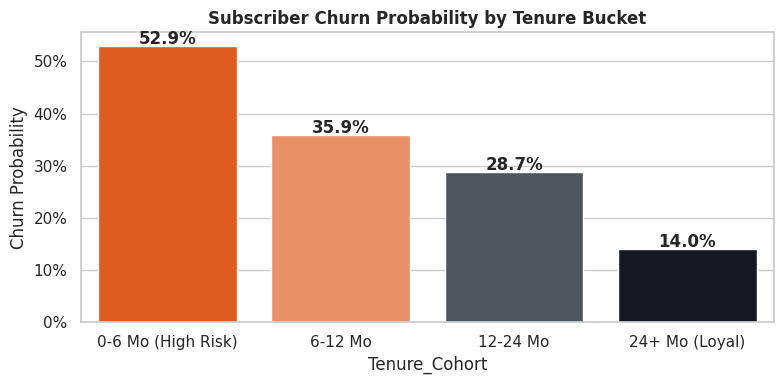

In [22]:
# Visualization: Tenure vs. Churn ---
plt.figure(figsize=(8, 4))
ax1 = sns.barplot(
    data=df.groupby('Tenure_Cohort', observed=False)['Churn_Numeric'].mean().reset_index(),
    x='Tenure_Cohort', y='Churn_Numeric', palette=[BL_ORANGE, '#FF8A50', '#4B5563', BL_NAVY]
)
plt.title('Subscriber Churn Probability by Tenure Bucket', fontweight='bold')
plt.ylabel('Churn Probability')
plt.gca().yaxis.set_major_formatter('{x:.0%}')

for p in ax1.patches:
    ax1.annotate(f"{p.get_height():.1%}", (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3189/1478397270.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


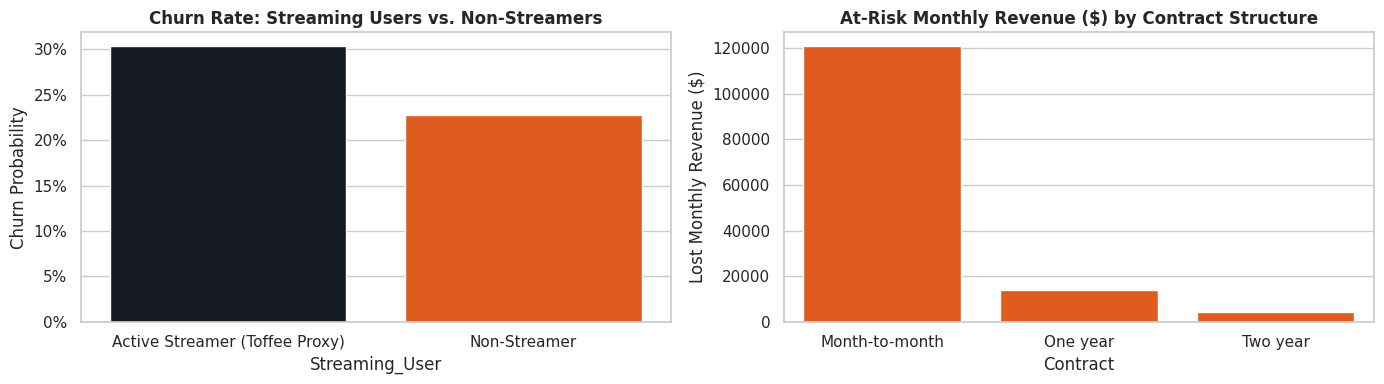

In [26]:
# Visualization: Streaming Engagement (Toffee Effect) & Contract Revenue ---
fig, (ax2, ax3) = plt.subplots(1, 2, figsize=(14, 4))

# Plot A: Streaming Engagement Impact
sns.barplot(
    data=df.groupby('Streaming_User')['Churn_Numeric'].mean().reset_index(),
    x='Streaming_User', y='Churn_Numeric', ax=ax2, palette=[BL_NAVY, BL_ORANGE]
)
ax2.set_title('Churn Rate: Streaming Users vs. Non-Streamers', fontweight='bold')
ax2.set_ylabel('Churn Probability')
ax2.yaxis.set_major_formatter('{x:.0%}')

# Plot B: Lost ARPU by Contract Type
rev_loss = df[df['Churn_Numeric'] == 1].groupby('Contract')['MonthlyCharges'].sum().reset_index()
sns.barplot(data=rev_loss, x='Contract', y='MonthlyCharges', ax=ax3, color=BL_ORANGE)
ax3.set_title('At-Risk Monthly Revenue ($) by Contract Structure', fontweight='bold')
ax3.set_ylabel('Lost Monthly Revenue ($)')

plt.tight_layout()
plt.show()

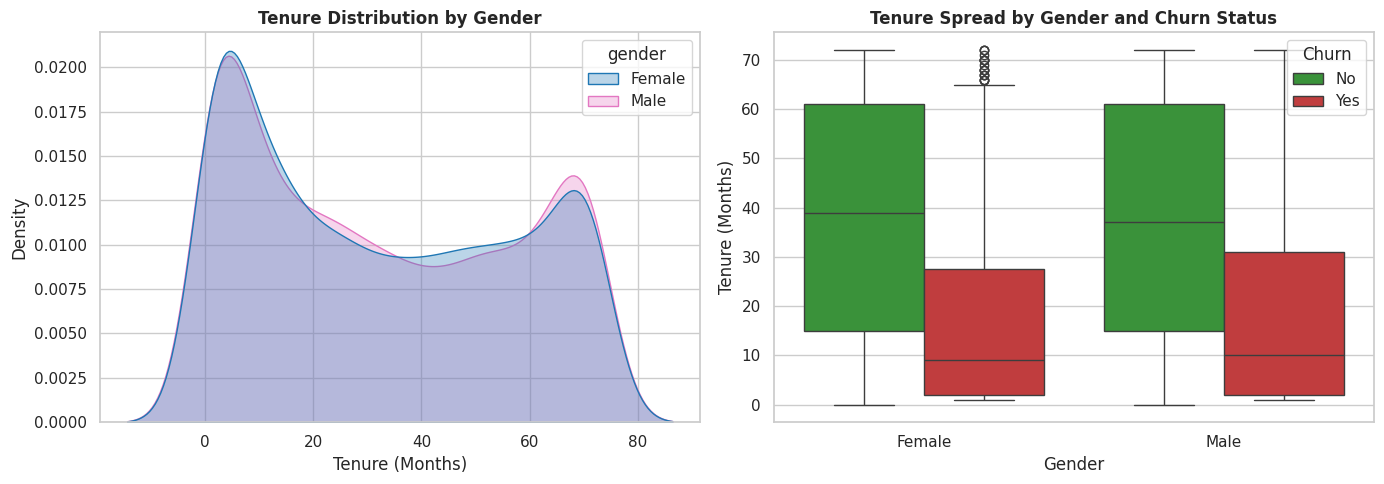

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Tenure Density Distribution by Gender
sns.kdeplot(
    data=df,
    x='tenure',
    hue='gender',
    common_norm=False,
    palette=['#1f77b4', '#e377c2'],
    ax=axes[0],
    fill=True,
    alpha=0.3
)
axes[0].set_title('Tenure Distribution by Gender', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Density')

# 2. Tenure Boxplot by Gender & Churn
sns.boxplot(
    data=df,
    x='gender',
    y='tenure',
    hue='Churn',
    palette=['#2ca02c', '#d62728'],
    ax=axes[1]
)
axes[1].set_title('Tenure Spread by Gender and Churn Status', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Tenure (Months)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_3189/2787590693.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


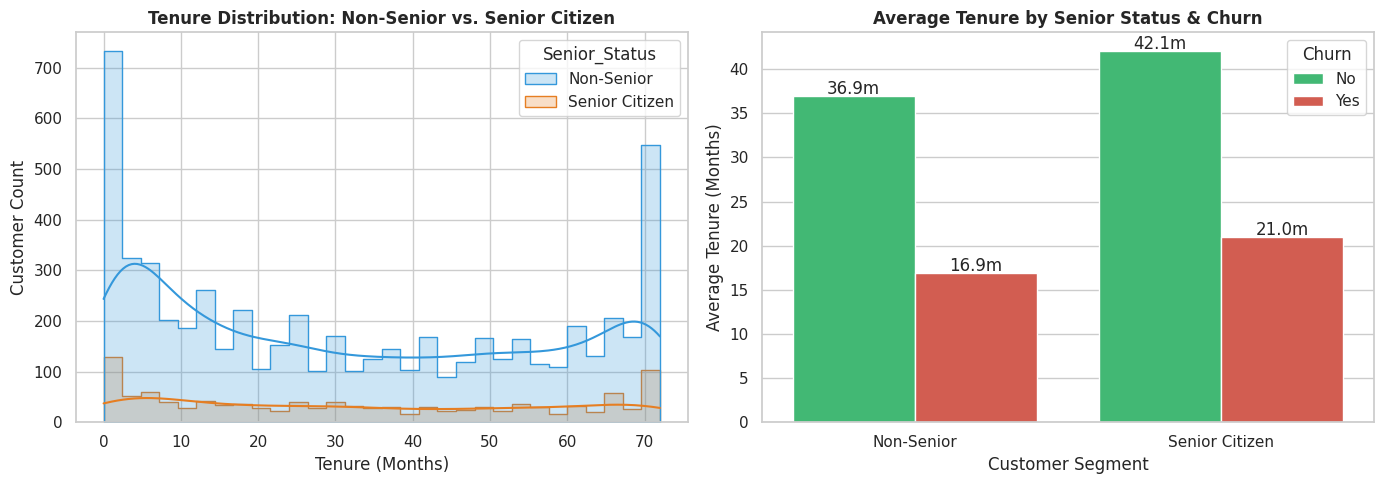

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map SeniorCitizen binary values to readable labels if not already done
df['Senior_Status'] = df['SeniorCitizen'].map({0: 'Non-Senior', 1: 'Senior Citizen'})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram Distribution by Senior Status
sns.histplot(
    data=df,
    x='tenure',
    hue='Senior_Status',
    kde=True,
    bins=30,
    palette=['#3498db', '#e67e22'],
    ax=axes[0],
    element="step"
)
axes[0].set_title('Tenure Distribution: Non-Senior vs. Senior Citizen', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Customer Count')

# Barplot of Mean Tenure by Senior Status and Churn
sns.barplot(
    data=df,
    x='Senior_Status',
    y='tenure',
    hue='Churn',
    palette=['#2ecc71', '#e74c3c'],
    ax=axes[1],
    ci=None
)
axes[1].set_title('Average Tenure by Senior Status & Churn', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Average Tenure (Months)')

# Annotate bar values
for p in axes[1].patches:
    if p.get_height() > 0:
        axes[1].annotate(
            f"{p.get_height():.1f}m",
            (p.get_x() + p.get_width() / 2., p.get_height()),
            ha='center', va='center', xytext=(0, 5), textcoords='offset points'
        )

plt.tight_layout()
plt.show()

### Commercial Summary Plot & Recommendations

In [29]:
# Predictive Modeling: Logistic Regression ---
features = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Contract', 'InternetService', 'PaymentMethod', 'PaperlessBilling']
X = pd.get_dummies(df[features], drop_first=True)
y = df['Churn_Numeric']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

print("--- Predictive Churn Model Performance ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_pred_prob):.3f}")
print(f"Precision:   {precision_score(y_test, (y_pred_prob > 0.5).astype(int)):.3f}")
print(f"Recall:      {recall_score(y_test, (y_pred_prob > 0.5).astype(int)):.3f}")

--- Predictive Churn Model Performance ---
ROC-AUC Score: 0.835
Precision:   0.629
Recall:      0.535


**Commercial Strategy Recommendations for Banglalink**

  Summarizing data findings into concrete recommendations aligned with VEON's Digital Operator Strategy:

  1. Structured Onboarding Journeys (0–90 Days):

     * Data Finding: Churn peaks sharply within the first 6 months (~53%+).

     * Action: Deploy automated MyBL app notifications offering a Day-30 and Day-60 bonus data booster for new SIM activations to build habituation.

  2. Toffee Quality of Experience (QoE) & Tailored Bundle Optimization:

     * Data Finding: Active streamers exhibit a 7% higher churn rate (~ 30%) compared to non-streamers (~ 23%), indicating potential dissatisfaction with video quality, buffering, high data consumption costs, or unoptimized bundle options.

     * Action: Improve the streaming experience by introducing zero-rated or low-cost dedicated Toffee data passes, coupled with network Quality of Service (QoS) optimization for video traffic to reduce churn among heavy streaming users.

  3. Digital Recharge Incentive Program:

     * Data Finding: Manual payment method users churn at higher rates than automated digital users.

     * Action: Offer a 5% cashback or bonus data allowance when subscribers recharge via digital channels (MyBL / bKash / Nagad auto-pay).

  4. Micro-Commitment Packs for Pay-As-You-Go Users:

     * Data Finding: Month-to-month contracts account for over 80% of total lost monthly spend.

     * Action: Introduce 3-month micro-commitment bundles with discounted pricing to transition month-to-month subscribers into predictable revenue streams.